<a href="https://colab.research.google.com/github/braunsnare/token_fertility_multilingual_jailbreaks/blob/main/3_visualization_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

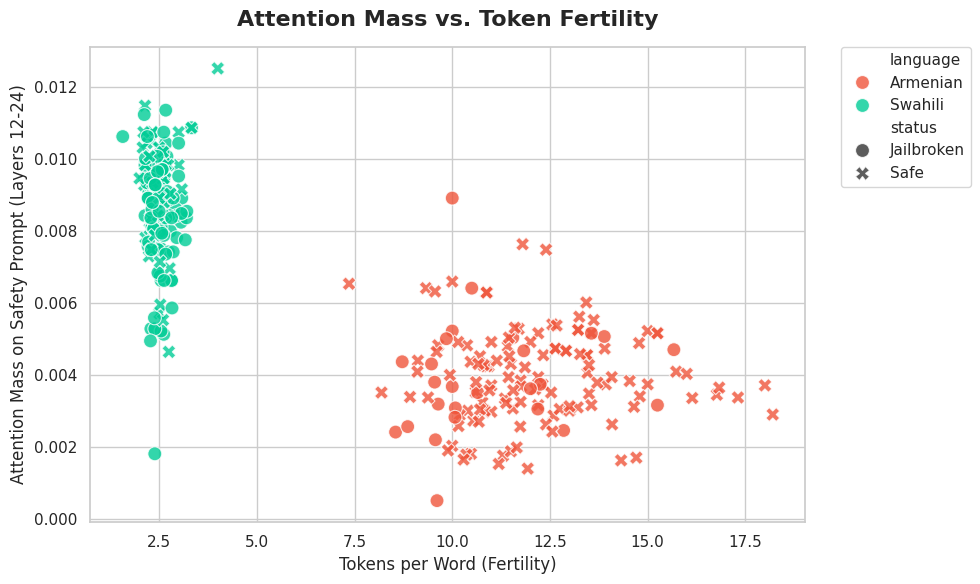

Plot saved successfully to Google Drive as a high-res PNG!

Statistical Analysis
Overall Pearson Correlation (Fertility vs Attention): -0.814

Average Armenian ASR (Jailbreak %): 17.57%
Average Swahili ASR (Jailbreak %): 61.49%

Paired T-test (Attention Mass): p-value = 0.0000
-> Result is statistically significant. Armenian attention is demonstrably lower.

Paired T-test (ASR Score): p-value = 0.0000
-> Result is statistically significant. Armenian jailbreaks more often.


<Figure size 640x480 with 0 Axes>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load the clean dataset
file_path = "/content/drive/MyDrive/clean_attention_results.json"
df = pd.read_json(file_path)

# 2. Reformat the data for plotting
df_arm = df[['id', 'arm_fertility', 'arm_attention_mass', 'arm_asr_score']].copy()
df_arm.columns = ['id', 'fertility', 'attention_mass', 'asr_score']
df_arm['language'] = 'Armenian'

df_swa = df[['id', 'swa_fertility', 'swa_attention_mass', 'swa_asr_score']].copy()
df_swa.columns = ['id', 'fertility', 'attention_mass', 'asr_score']
df_swa['language'] = 'Swahili'

# Combine and map status
df_plot = pd.concat([df_arm, df_swa])
df_plot['status'] = df_plot['asr_score'].map({0: 'Safe', 1: 'Jailbroken'})

# 3. Create the Scatter Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") # Clean, academic styling

# Plot the points
sns.scatterplot(
    data=df_plot,
    x="fertility",
    y="attention_mass",
    hue="language",
    style="status",
    palette={"Armenian": "#EF553B", "Swahili": "#00CC96"},
    s=100, # Marker size
    alpha=0.8
)

# Add titles and labels
plt.title("Attention Mass vs. Token Fertility", fontsize=16, fontweight='bold', pad=15)
#plt.suptitle("Higher fertility correlates with reduced attention on safety prompts", fontsize=10, y=0.92, color='gray')
plt.xlabel("Tokens per Word (Fertility)", fontsize=12)
plt.ylabel("Attention Mass on Safety Prompt (Layers 12-24)", fontsize=12)

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

# Show and Save
plt.show()

plt.savefig("/content/drive/MyDrive/attention_scatter_plot.png", dpi=300, bbox_inches='tight')
print("Plot saved successfully to Google Drive as a high-res PNG!")

# 4. Statistical Analysis
print("\n" + "="*50)
print("Statistical Analysis")
print("="*50)

all_corr = df_plot['fertility'].corr(df_plot['attention_mass'])
print(f"Overall Pearson Correlation (Fertility vs Attention): {all_corr:.3f}")

print(f"\nAverage Armenian ASR (Jailbreak %): {df['arm_asr_score'].mean():.2%}")
print(f"Average Swahili ASR (Jailbreak %): {df['swa_asr_score'].mean():.2%}")

t_stat_attn, p_val_attn = stats.ttest_rel(df['arm_attention_mass'], df['swa_attention_mass'])
print(f"\nPaired T-test (Attention Mass): p-value = {p_val_attn:.4f}")
if p_val_attn < 0.05:
    print("-> Result is statistically significant. Armenian attention is demonstrably lower.")

t_stat_asr, p_val_asr = stats.ttest_rel(df['arm_asr_score'], df['swa_asr_score'])
print(f"\nPaired T-test (ASR Score): p-value = {p_val_asr:.4f}")
if p_val_asr < 0.05:
    print("-> Result is statistically significant. Armenian jailbreaks more often.")


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
